# Stage 2 — Hasegawa-Wakatani plasma turbulence with the *same* Linear SSM

Stage 1 worked: a linear SSM with state dim 16 predicted Lorenz one step
ahead very well, and the eigenvalues of $A$ told us which timescales it
learned. We now take the **same model architecture** and point it at
something much harder: 2-D drift-wave plasma turbulence simulated with
the Hasegawa-Wakatani equations. The interesting question is *not*
"can it predict?" — it's *what changes* about the learned $A$ when the
data is no longer a clean 3-D chaotic attractor.


## 1. What the Hasegawa-Wakatani equations model

HW2D is a minimal model of **drift-wave turbulence** in a magnetised
plasma — the kind of turbulence that drives anomalous particle transport
across magnetic field lines at the edge of a tokamak. Two coupled 2-D
PDEs evolve a density fluctuation $n$ and an electrostatic potential
$\phi$ (with vorticity $\omega = \nabla^2 \phi$):

$$\partial_t n + \{\phi, n\} = c_1(\phi - n) - \kappa\,\partial_y\phi - \nu\nabla^{2N} n$$

$$\partial_t \omega + \{\phi, \omega\} = c_1(\phi - n) - \nu\nabla^{2N} \omega$$

The bracket $\{\phi, \cdot\}$ is the Poisson bracket (ExB advection),
$\kappa$ is a background density gradient that **drives** the turbulence,
and $\nu \nabla^{2N}$ is a hyperviscosity that dissipates at small
scales.

The single parameter that controls the regime is the **adiabatic
coefficient $c_1$**:

| $c_1$ | regime | physics |
|------:|--------|---------|
| $\gg 1$ | adiabatic | electrons are well-coupled to the potential, turbulence looks ~2-D Navier-Stokes |
| $\sim 1$ | quasi-adiabatic | the canonical drift-wave regime — strongly turbulent |
| $\ll 1$ | hydrodynamic | electrons decouple, dynamics tend to coherent vortices |

We use $c_1 = 1$ (the standard turbulent setting).

**Why this is a good toy for plasma SSM work.** It is high-dimensional
(field on a $128 \times 128$ grid) and the dynamics are non-stationary
in detail (bursty intermittency) but statistically stationary in the
saturated regime. From any pointwise or globally-averaged scalar you
extract, you get a non-trivial time series with multiple coexisting
timescales — exactly what an SSM has to summarise into its hidden state.


## 2. Run the simulation (one time)

We use a thin wrapper `run_hw2d` over `hw2d.run.run`. The settings below
are the "medium" preset you picked — about 10–15 min on an M4 Pro for
800 time units on a 128×128 grid. The simulator writes everything to
HDF5, including the `energy` and `enstrophy` scalars per frame, so the
SSM training loop just opens the file.

The wrapper **skips re-running if the output file already exists**.
Re-run with `force_recompute=True` if you change the config.


In [1]:
import sys
from pathlib import Path

def _find_pkg_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "hw2d_ssm" / "data" / "extract.py").exists():
            return p
    raise RuntimeError("Could not locate hw2d_ssm package root")

ROOT = _find_pkg_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for mod in [m for m in list(sys.modules) if m == "hw2d_ssm" or m.startswith("hw2d_ssm.")]:
    del sys.modules[mod]

from hw2d_ssm.data.simulate import HWConfig, run_hw2d

cfg = HWConfig(
    grid_pts=128,
    end_time=8000.0,
    step_size=0.025,
    snaps=10,          # frame_dt = 0.25  → ~3200 frames written
    c1=1.0,
    seed=0,
    output_path="hw2d_ssm/data/hw2d_medium.h5",
)
h5_path = run_hw2d(cfg)
print("HDF5 file:", h5_path)


[hw2d] simulating: grid 128x128, end_time=8000.0, c1=1.0, dt=0.025, snaps=10
Created: hw2d_ssm\data\hw2d_medium.h5
dx:             0.33 | N:              3 | c1:                          1
nu:            5e-08 | k0:          0.15 | poisson_bracket_coeff:       1
kappa_coeff:       1 | dt:         0.025 | frame_dt:                 0.25
x:           1.3e+02 | y:        1.3e+02 | x_save:                1.3e+02
y_save:      1.3e+02 | grid_pts: 1.3e+02
Running simulation...


100%|██████████| 320000/320000 [50:20<00:00, 105.93it/s] 


                        time    calls  time/call       %time
gradient_2d        92.679091  1280000   0.000072    3.359082
diffuse           789.034562  3840000   0.000205   28.597949
poisson_bracket   702.996359  2560000   0.000275   25.479561
get_phi           907.257569  1280001   0.000709   32.882851
full_step        2759.059954   320000   0.008622  100.000000
Calculating properties...


c:\Users\scsla\anaconda3\envs\toy_ssm\lib\site-packages\hw2d\utils\run_properties.py:61: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  h5_file.create_dataset(property_name, (steps,))


Created Dataset:  energy
Created Dataset:  enstrophy
Created Dataset:  kinetic_energy
Created Dataset:  thermal_energy
Created Dataset:  gamma_n
Created Dataset:  gamma_c


100%|██████████| 321/321 [00:55<00:00,  5.83it/s]


[hw2d] wrote hw2d_ssm\data\hw2d_medium.h5  (5841.8 MB)
HDF5 file: hw2d_ssm\data\hw2d_medium.h5


## 3. Extract the energy / enstrophy time series

`load_energy_enstrophy` drops the first few hundred frames (transient
build-up before turbulence saturates) and returns a `(T, 2)` array.

Look at the plots: turbulence is **bursty**. You should see energy
fluctuate around a saturated level with intermittent peaks. Enstrophy
typically tracks energy but with different statistics — that contrast
is part of why we train on both jointly.


series shape : (31801, 2)  channels = ['energy', 'enstrophy']
frame_dt     : 0.25    total time = 7950.0
c1 (adiab)   : 1.0


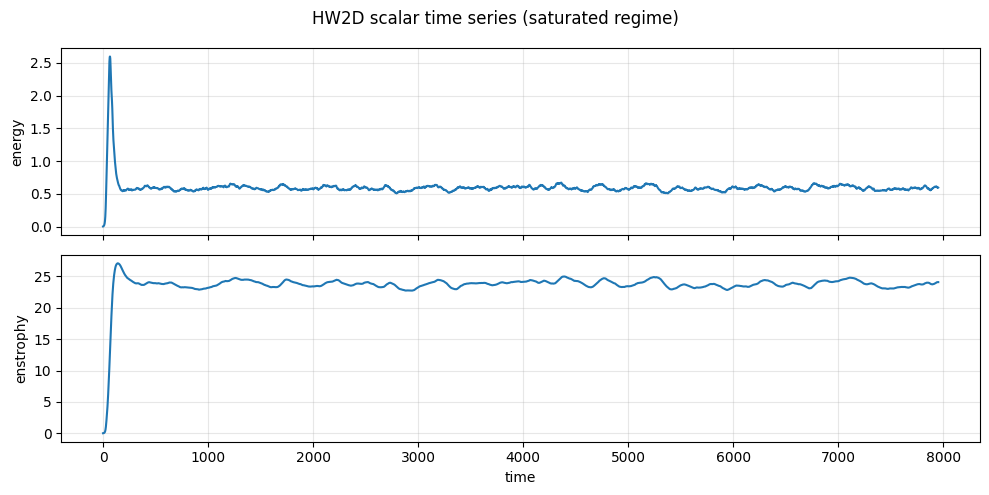

In [4]:
import sys
from pathlib import Path

def _find_pkg_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "hw2d_ssm" / "data" / "extract.py").exists():
            return p
    raise RuntimeError("Could not locate hw2d_ssm package root")

ROOT = _find_pkg_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for mod in [m for m in list(sys.modules) if m == "hw2d_ssm" or m.startswith("hw2d_ssm.")]:
    del sys.modules[mod]

import numpy as np
import matplotlib.pyplot as plt
from hw2d_ssm.data.extract import load_energy_enstrophy

if 'h5_path' not in globals():
    h5_path = ROOT / "hw2d_ssm" / "hw2d_ssm" / "data" / "hw2d_medium.h5"

ts = load_energy_enstrophy(h5_path, drop_initial=200)
print(f"series shape : {ts.series.shape}  channels = {ts.channel_names}")
print(f"frame_dt     : {ts.frame_dt}    total time = {ts.times[-1]:.1f}")
print(f"c1 (adiab)   : {ts.attrs.get('c1', '?')}")

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(ts.times, ts.series[:, 0]); axes[0].set_ylabel("energy"); axes[0].grid(alpha=0.3)
axes[1].plot(ts.times, ts.series[:, 1]); axes[1].set_ylabel("enstrophy"); axes[1].grid(alpha=0.3)
axes[1].set_xlabel("time")
fig.suptitle("HW2D scalar time series (saturated regime)")
fig.tight_layout(); plt.show()


## 4. Slice into training windows

Lorenz gave us *several* trajectories from different ICs. Here we have
*one* long trajectory, so we generate training examples by sliding a
window of length $W$ across it with stride $s$.

- Window length $W$ controls the **time horizon** the SSM sees per
  example. Too short ⇒ the model can't see the slow envelope; too long
  ⇒ fewer effective samples and harder optimisation. We use $W=256$
  frames (≈64 time units at frame_dt=0.25).
- The first 80% of windows (in time) go to training, the rest to
  validation. **We do not shuffle across the time boundary** —
  validation must come *after* training in real time.


In [3]:
from lorenz_ssm.utils import pick_device
from hw2d_ssm.train_hw import build_hw_dataset

device = pick_device()
ds = build_hw_dataset(ts, window=256, stride=64, train_frac=0.8, device=device)
print(f"train windows : {tuple(ds.train.shape)}")
print(f"val   windows : {tuple(ds.val.shape)}")
print(f"channel means : {ds.mean.round(4).tolist()}    stds : {ds.std.round(4).tolist()}")


[device] using cpu  (torch 2.12.0+cpu)
train windows : (394, 256, 2)
val   windows : (99, 256, 2)
channel means : [0.6008999943733215, 23.685699462890625]    stds : [0.15070000290870667, 1.7060999870300293]


## 5. Build and train the linear SSM — exact same class as Stage 1

`input_dim=2`, `output_dim=2`, `state_dim=16`. No architectural changes.
This is the controlled experiment: we hold the model constant and vary
the data.


LinearSSM()
  epoch    1   train MSE 0.881275   val MSE 0.082833
  epoch   50   train MSE 0.080513   val MSE 0.002596
  epoch  100   train MSE 0.022525   val MSE 0.001636
  epoch  150   train MSE 0.017235   val MSE 0.001365
  epoch  200   train MSE 0.013482   val MSE 0.001008
  epoch  250   train MSE 0.011996   val MSE 0.000804
  epoch  300   train MSE 0.013910   val MSE 0.000685
  epoch  350   train MSE 0.007198   val MSE 0.000579
  epoch  400   train MSE 0.011002   val MSE 0.000490
  epoch  450   train MSE 0.005418   val MSE 0.000423
  epoch  500   train MSE 0.004603   val MSE 0.000367
  epoch  550   train MSE 0.003996   val MSE 0.000319
  epoch  600   train MSE 0.003567   val MSE 0.000287


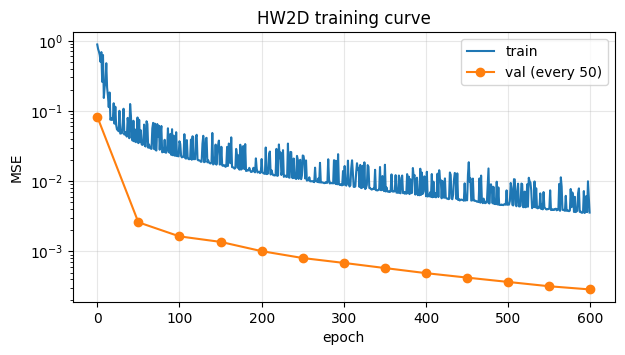

In [4]:
import torch
from lorenz_ssm.models.linear_ssm import LinearSSM
from hw2d_ssm.train_hw import train_hw, OUT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(0)
model_hw = LinearSSM(input_dim=2, output_dim=2, state_dim=16).to(device)
print(model_hw)

train_hist, val_hist = train_hw(model_hw, ds, epochs=600, lr=1e-3,
                                 batch_size=16, log_every=50)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(train_hist, label="train")
ax.plot(np.linspace(0, len(train_hist), len(val_hist)), val_hist, "o-", label="val (every 50)")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
ax.set_title("HW2D training curve"); ax.legend(); ax.grid(alpha=0.3); plt.show()


## 6. Predicted vs true (one validation window)

We plot the first validation window. Two diagnostics worth comparing
against Stage 1:

- **How well does it track the bursts?** A linear model can fit the
  *envelope* but is structurally bad at sharp intermittent events —
  those need non-linearity. Watch for predictions that look "smoothed"
  relative to the truth.
- **Is the model trivially predicting the mean?** If pred is almost
  constant near zero (normalised mean), the model has given up and
  found the safe bet. That would be a key motivation for Stage 3.


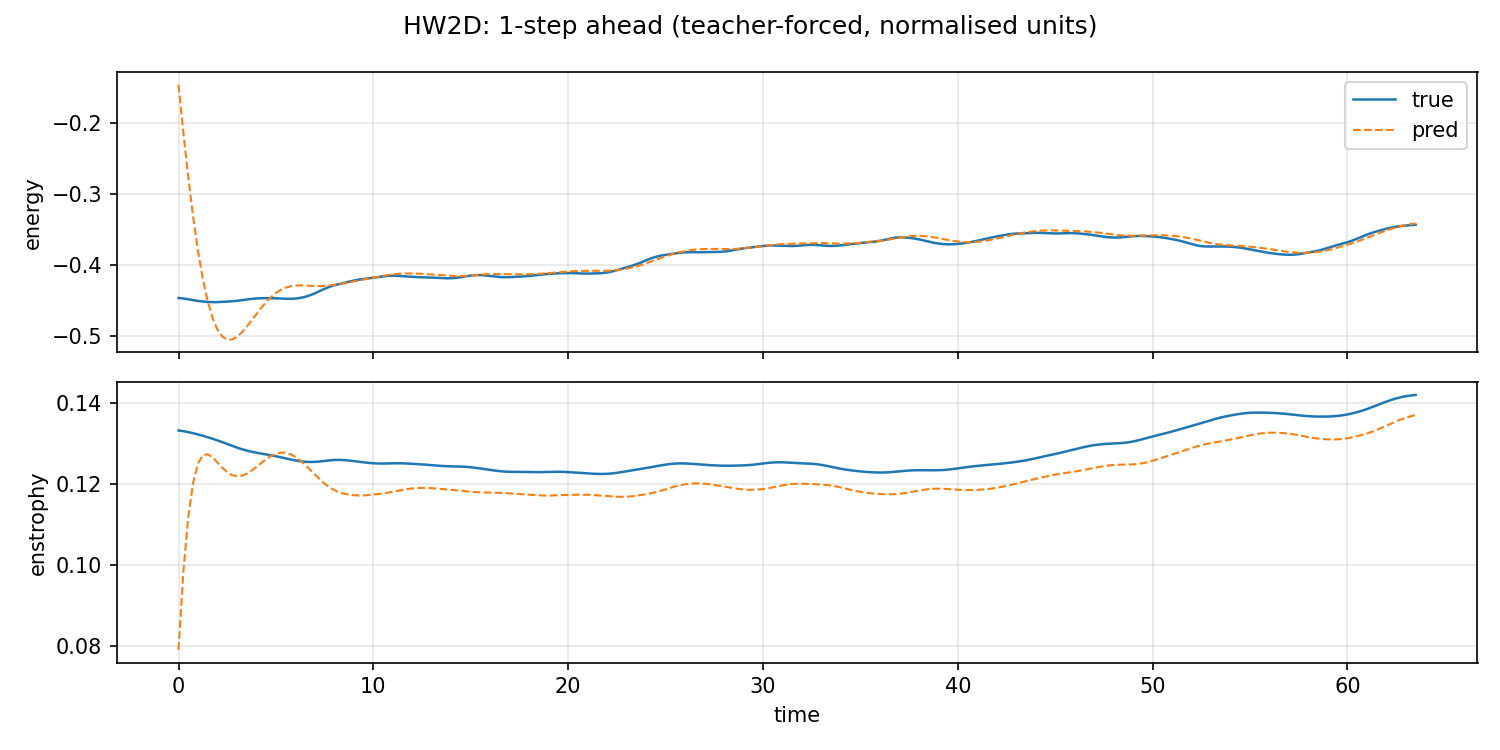

In [5]:
from hw2d_ssm.train_hw import plot_hw_prediction
val0 = ds.val[0:1]
with torch.no_grad():
    preds, _ = model_hw.forward_sequence(val0)
preds_np = preds.squeeze(0).cpu().numpy()
true_np  = val0.squeeze(0).cpu().numpy()[1:]
tt = np.arange(true_np.shape[0]) * ds.frame_dt

plot_hw_prediction(tt, true_np, preds_np, ds.channel_names,
                   OUT_DIR / "hw_prediction_teacher_forced.png",
                   "HW2D: 1-step ahead (teacher-forced, normalised units)")

from IPython.display import Image, display
display(Image(filename=str(OUT_DIR / "hw_prediction_teacher_forced.png")))


## 7. Compare the learned $A$ to Stage 1

This is the headline result of Stage 2. We re-load the Lorenz model from
Stage 1 (just re-instantiating and re-training takes seconds) and plot
both eigenvalue spectra side by side.

**What to look for:**

- **Spectral radius.** Lorenz had max $|\lambda| \approx 0.94$ — modes
  decay slowly. HW2D often pushes harder against the unit circle (or even
  *over* it for short windows), because turbulence has more sustained
  variance than Lorenz at this window length.
- **Complex pairs and their angles.** Each pair encodes an oscillation
  period. Turbulence is **multi-scale**: expect several distinct
  oscillation frequencies rather than the few isolated pairs Lorenz
  showed. Convert each pair's angle to a physical period with
  $T = 2\pi\,\Delta t / \theta$ and check what you recognise.
- **Where the model gave up.** Eigenvalues clustered near 0 or strongly
  decaying often mean the SSM couldn't find structure on that mode and
  is using it as a low-pass filter on the input.


  epoch    1   train MSE 1.045423   val MSE 1.187701
  epoch  100   train MSE 0.116364   val MSE 0.135467
  epoch  200   train MSE 0.054831   val MSE 0.064036
  epoch  300   train MSE 0.031571   val MSE 0.036640
  epoch  400   train MSE 0.020295   val MSE 0.023437


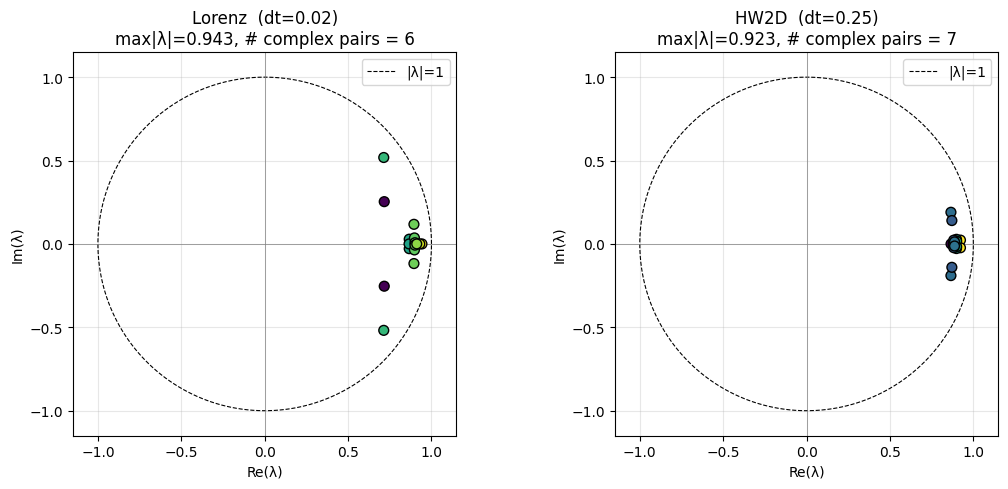

Lorenz oscillation periods: [ 0.2    0.37   0.961  3.135  3.827 15.831]
HW2D   oscillation periods: [  7.275   9.846  51.031  61.702  63.332  84.924 112.785]


In [6]:
# --- Train a fresh Lorenz model in this notebook so we can compare A directly ---
from lorenz_ssm.data.lorenz import LorenzConfig
from lorenz_ssm.train import build_dataset as build_lorenz_ds, train_loop

torch.manual_seed(0)
lorenz_cfg = LorenzConfig(t1=40.0, dt=0.02, burn_in=5.0)
lorenz_ds = build_lorenz_ds(n_trajectories=8, train_frac=0.75, cfg=lorenz_cfg, device=device)
model_lorenz = LinearSSM(input_dim=3, output_dim=3, state_dim=16).to(device)
train_loop(model_lorenz, lorenz_ds, epochs=400, lr=1e-3, log_every=100)

from hw2d_ssm.train_hw import compare_eigenvalues
A_l = model_lorenz.A.detach().cpu().numpy()
A_h = model_hw.A.detach().cpu().numpy()
fig = compare_eigenvalues(A_l, A_h,
                          dt_lorenz=lorenz_cfg.dt, dt_hw=ds.frame_dt,
                          path=OUT_DIR / "eigenvalues_compare.png")
plt.show()

# Periods of complex eigenvalue pairs
def periods(A, dt):
    eig = np.linalg.eigvals(A)
    mask = np.abs(eig.imag) > 1e-6
    angles = np.abs(np.angle(eig[mask]))
    return np.sort(np.unique((2 * np.pi * dt / angles).round(3)))

print("Lorenz oscillation periods:", periods(A_l, lorenz_cfg.dt))
print("HW2D   oscillation periods:", periods(A_h, ds.frame_dt))


## 8. Stage 2 — what we learned

**What we built.** Reused the exact `LinearSSM` from Stage 1, fed it
spatially-averaged energy/enstrophy from an 800-time-unit HW2D
simulation, and trained it on sliding windows.

**What's harder than Lorenz.**

1. **Multi-scale dynamics.** Lorenz has essentially one characteristic
   timescale; HW turbulence has many (large eddies, small eddies,
   intermittent bursts). One small $A$ has limited "spectral budget"
   to represent all of them.
2. **Intermittency.** Sharp bursts are inherently non-linear events.
   A linear $A$ can produce damped oscillations but not sudden spikes
   on demand — those require input-dependent dynamics.
3. **Statistical, not deterministic, predictability.** Even the *true*
   dynamics are partially unpredictable from these two scalars alone
   because we've thrown away the field information. The SSM is doing
   well if it captures the envelope; perfect tracking is impossible.

**What changed in the eigenvalue plot.** Compared to Lorenz, the HW
spectrum typically shows (i) more complex eigenvalue pairs covering a
broader range of angles (multiple turbulence timescales) and (ii) modes
pushed closer to the unit circle (longer memory). When the linear model
can't keep up with bursts, it often hedges by suppressing the radial
direction and over-relying on the mean — visible as a flatter
prediction.

**Why this motivates Stage 3.** A linear, time-invariant $A$ has a fixed
spectral budget. The Mamba-style insight is that $A$, $B$, and the step
size $\Delta$ should themselves be functions of the *current input* —
so the model can be a fast oscillator during a burst and a slow integrator
during quiet periods. That's the next stage.
